In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import os
os.environ["OMP_NUM_THREADS"] = "1"

from sklearn.cluster import KMeans

In [5]:
df = pd.read_csv('Mall_Customers.csv')

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())

(200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.0

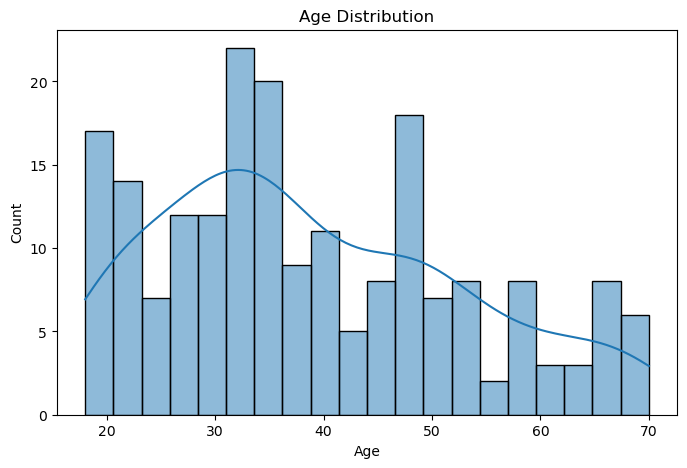

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.show()

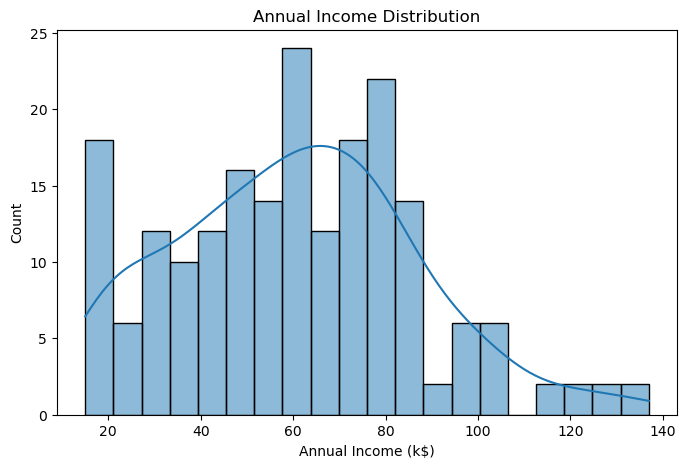

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df['Annual Income (k$)'], bins=20, kde=True)
plt.title('Annual Income Distribution')
plt.show()

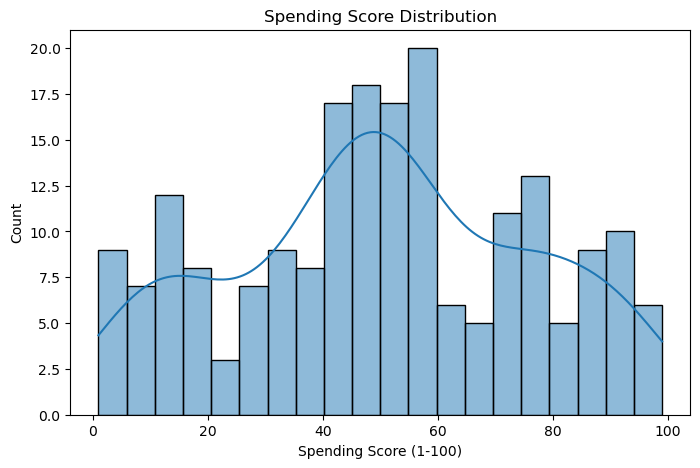

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['Spending Score (1-100)'], bins=20, kde=True)
plt.title('Spending Score Distribution')
plt.show()

In [10]:
X = df[['Annual Income (k$)',
        'Spending Score (1-100)']]

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

C:\Users\umang\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\umang\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\umang\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\umang\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Window

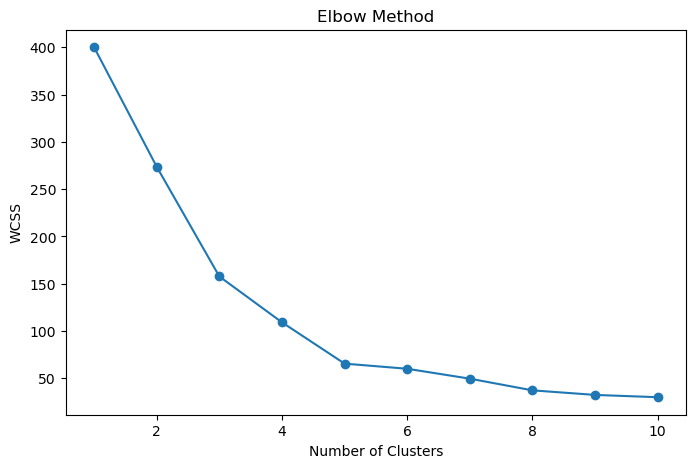

In [12]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42
    )

    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [13]:
kmeans = KMeans(
    n_clusters=5,
    init='k-means++',
    random_state=42
)

y_pred = kmeans.fit_predict(X_scaled)

df['Cluster'] = y_pred

C:\Users\umang\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


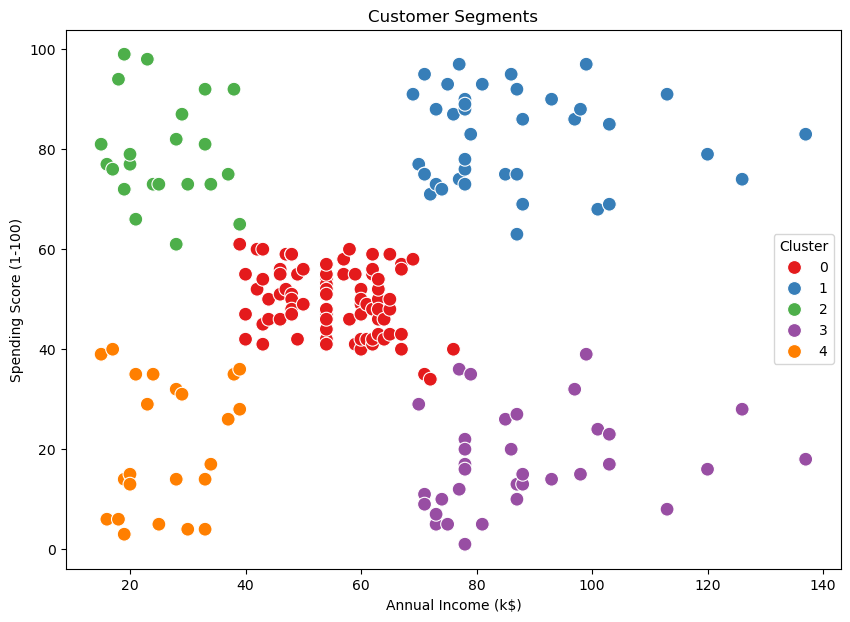

In [14]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1',
    s=100
)

plt.title('Customer Segments')
plt.show()

In [15]:
print(df.groupby('Cluster').mean(numeric_only=True))

         CustomerID        Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                                   
0         86.320988  42.716049           55.296296               49.518519
1        162.000000  32.692308           86.538462               82.128205
2         23.090909  25.272727           25.727273               79.363636
3        164.371429  41.114286           88.200000               17.114286
4         23.000000  45.217391           26.304348               20.913043


In [16]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, y_pred)
print("Silhouette Score:", score)

Silhouette Score: 0.5546571631111091


In [17]:
cluster_summary = df.groupby('Cluster').mean(numeric_only=True)
print(cluster_summary)

         CustomerID        Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                                   
0         86.320988  42.716049           55.296296               49.518519
1        162.000000  32.692308           86.538462               82.128205
2         23.090909  25.272727           25.727273               79.363636
3        164.371429  41.114286           88.200000               17.114286
4         23.000000  45.217391           26.304348               20.913043


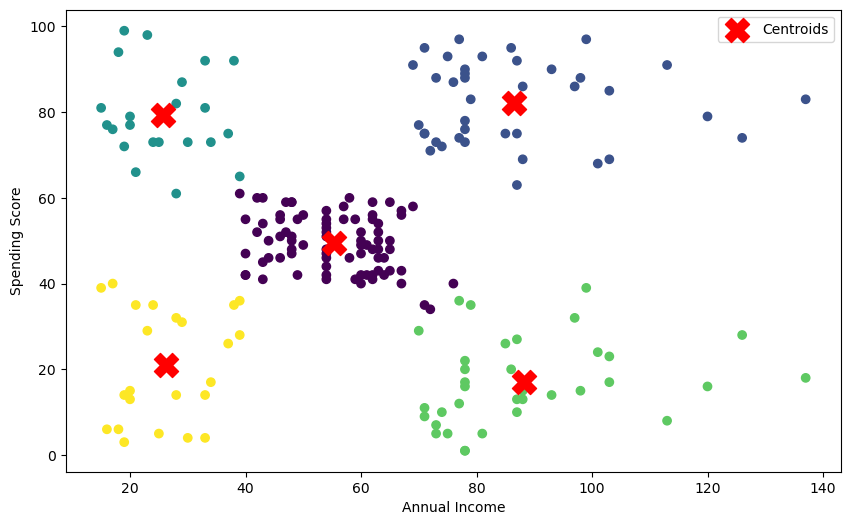

In [20]:
plt.figure(figsize=(10,6))
plt.scatter(df['Annual Income (k$)'],
            df['Spending Score (1-100)'],
            c=df['Cluster'],
            cmap='viridis')

centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers[:,0], centers[:,1],
            s=300,
            c='red',
            marker='X',
            label='Centroids')

plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend()
plt.show()

In [21]:
for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K={k}, Silhouette Score={score}")

K=2, Silhouette Score=0.3973270007887498
K=3, Silhouette Score=0.46658474419000145
K=4, Silhouette Score=0.49434988482196784
K=5, Silhouette Score=0.5546571631111091
K=6, Silhouette Score=0.5138257534676561
K=7, Silhouette Score=0.50200146805547


C:\Users\umang\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\umang\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\umang\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\umang\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Window

In [22]:
business_recommendations = pd.DataFrame({
    'Cluster':[0,1,2,3,4],
    'Customer Type':['Premium Customers',
                     'Budget Customers',
                     'Potential Customers',
                     'Careful Customers',
                     'Regular Customers'],
    'Strategy':['VIP memberships and loyalty programs',
                'Discounts and coupons',
                'Personalized recommendations and affordable premium products',
                'Targeted marketing campaigns',
                'Reward points and seasonal promotions']
})

print(business_recommendations)

   Cluster        Customer Type  \
0        0    Premium Customers   
1        1     Budget Customers   
2        2  Potential Customers   
3        3    Careful Customers   
4        4    Regular Customers   

                                            Strategy  
0               VIP memberships and loyalty programs  
1                              Discounts and coupons  
2  Personalized recommendations and affordable pr...  
3                       Targeted marketing campaigns  
4              Reward points and seasonal promotions  


In [23]:
business_recommendations #The customer segmentation analysis identified five distinct customer groups based on annual income and spending behavior. 
                         #These segments can help businesses design targeted marketing strategies, improve customer retention, optimize promotional campaigns, and increase overall revenue. 
                         #Premium customers can be retained through loyalty programs, budget customers can be attracted through discounts, and potential customers can be converted through personalized marketing strategies.

,Cluster,Customer Type,Strategy
0,0,Premium Customers,VIP memberships and loyalty programs
1,1,Budget Customers,Discounts and coupons
2,2,Potential Customers,Personalized recommendations and affordable pr...
3,3,Careful Customers,Targeted marketing campaigns
4,4,Regular Customers,Reward points and seasonal promotions
